# Implementación de una GNN con Grafos Obtenidos a Partir de Nudos

In [1]:
import pandas as pd
import numpy as np
import ast
import networkx as nx
import matplotlib.pyplot as plt
import spherogram
import json

import warnings

## Functions

In [2]:
def str2graph(graph):
    return ast.literal_eval(graph)

In [3]:
def draw_graph(graph):
    if type(graph) == str:
        graph = str2graph(graph)

    if type(graph) != dict:
        warnings.warn("The graph is not a dictionary or string representation of a dictionary.")
        return None
    
    graph = nx.node_link_graph(graph, edges="links")
    # Generate a layout for the nodes
    pos = nx.planar_layout(graph)

    # Draw the graph with labels
    plt.figure(figsize=(10, 6))
    nx.draw_networkx(graph, pos, with_labels=True, node_color='lightgreen', edge_color='gray', node_size=800)
    plt.title("Visualization of the Graph")
    plt.axis('off')
    plt.show()

In [4]:
def draw_knot(pd_notation):
    """
    This function draws a knot based on the PD Notation.
    Input:
        - A string with the PD Notation using ";" as separators.
    Output:
        - A graphic with the knot.
    """
    pd_notation = json.loads(pd_notation.replace(";", ","))
    knot = spherogram.Link(pd_notation)
    knot.view()
    %gui tk
    

## Read the Dataset

In [5]:
# Read the dataset...
data = pd.read_csv('datasets/knotinfoWithGraph.csv')

<Axes: >

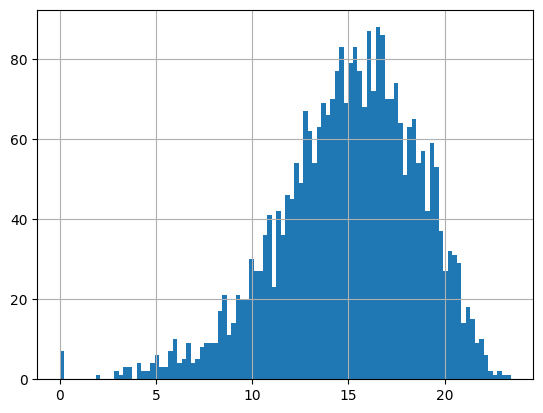

In [6]:
data['Volume'].hist(bins = 100)

## Some Graphic Examples

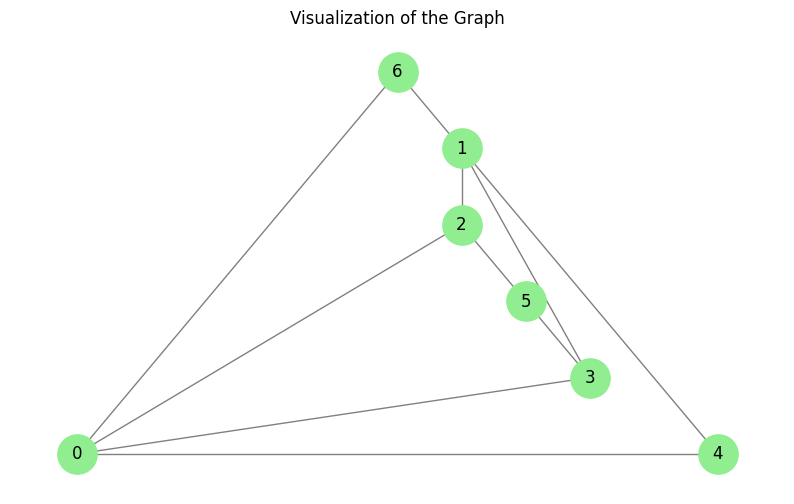

In [7]:
draw_graph(data['graph'][2])

In [8]:
draw_knot(data['PD Notation'][2])

## Show Distributions

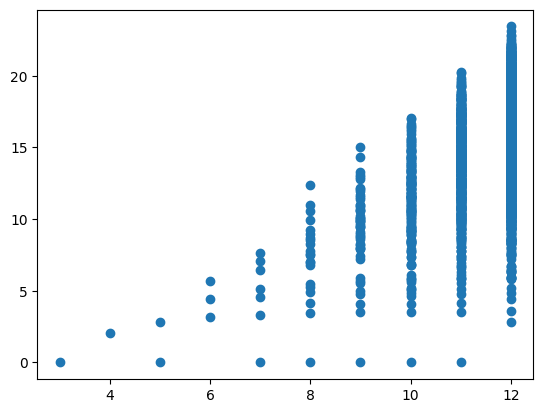

In [9]:
plt.scatter(data["Crossing Number"], data["Volume"])